In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/processed/training.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5152 entries, 0 to 5151
Data columns (total 63 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_OS            5152 non-null   int64  
 1   A2_OS            5152 non-null   int64  
 2   B1_OS            5152 non-null   int64  
 3   B2_OS            5152 non-null   int64  
 4   Insulator        5152 non-null   int64  
 5   PBE_band_gap     5152 non-null   float64
 6   stable           5152 non-null   int64  
 7   X-A1             5152 non-null   float64
 8   X-A2             5152 non-null   float64
 9   X-B1             5152 non-null   float64
 10  X-B2             5152 non-null   float64
 11  I-A1             5152 non-null   float64
 12  I-A2             5152 non-null   float64
 13  I-B1             5152 non-null   float64
 14  I-B2             5152 non-null   float64
 15  P-A1             5152 non-null   float64
 16  P-A2             5152 non-null   float64
 17  P-B1          

In [3]:
df.columns

Index(['A1_OS', 'A2_OS', 'B1_OS', 'B2_OS', 'Insulator', 'PBE_band_gap',
       'stable', 'X-A1', 'X-A2', 'X-B1', 'X-B2', 'I-A1', 'I-A2', 'I-B1',
       'I-B2', 'P-A1', 'P-A2', 'P-B1', 'P-B2', 'R-A1', 'R-A2', 'R-B1', 'R-B2',
       'RA-A1', 'RA-A2', 'RA-B1', 'RA-B2', 'H-A1', 'H-A2', 'H-B1', 'H-B2',
       'L-A1', 'L-A2', 'L-B1', 'L-B2', 'EA-A1', 'EA-A2', 'EA-B1', 'EA-B2',
       'TC-A1', 'TC-A2', 'TC-B1', 'TC-B2', 'TE-A1', 'TE-A2', 'TE-B1', 'TE-B2',
       'EH-A1', 'EH-A2', 'EH-B1', 'EH-B2', 'BE-A1', 'BE-A2', 'BE-B1', 'BE-B2',
       '3DOE-A1', '3DOE-A2', '3DOE-B1', '3DOE-B2', 'type_A1A2B1B2O6',
       'type_A1A2B2O6', 'type_A2B1B2O6', 'type_ABO3'],
      dtype='object')

In [4]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix['PBE_band_gap'].sort_values(ascending=False))

PBE_band_gap    1.000000
Insulator       0.897896
H-B1            0.305857
H-B2            0.292482
P-A1            0.206588
                  ...   
X-B2           -0.199066
X-A1           -0.205125
I-B2           -0.235483
X-B1           -0.246826
I-B1           -0.258936
Name: PBE_band_gap, Length: 63, dtype: float64

In [5]:
from scipy.stats import pearsonr, spearmanr, kendalltau

correlation_results = {}

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('PBE_band_gap')


for col in numeric_cols:

    temp_df = df[[col, 'PBE_band_gap']].dropna()
    if len(temp_df) > 1:
        pearson_corr, _ = pearsonr(temp_df[col], temp_df['PBE_band_gap'])
        spearman_corr, _ = spearmanr(temp_df[col], temp_df['PBE_band_gap'])
        kendall_corr, _ = kendalltau(temp_df[col], temp_df['PBE_band_gap'])

        correlation_results[col] = {
            'Pearson': pearson_corr,
            'Spearman': spearman_corr,
            'Kendall': kendall_corr
        }
    else:
        correlation_results[col] = {
            'Pearson': None,
            'Spearman': None,
            'Kendall': None
        }



for col, corrs in correlation_results.items():
    print(f"Correlations with PBE_band_gap for column '{col}':")
    for method, value in corrs.items():
        print(f"  {method}: {value:.4f}" if value is not None else f"  {method}: Insufficient data")
    print("-" * 20)

Correlations with PBE_band_gap for column 'A1_OS':
  Pearson: -0.0945
  Spearman: -0.0628
  Kendall: -0.0540
--------------------
Correlations with PBE_band_gap for column 'A2_OS':
  Pearson: 0.0803
  Spearman: 0.0686
  Kendall: 0.0556
--------------------
Correlations with PBE_band_gap for column 'B1_OS':
  Pearson: -0.0835
  Spearman: -0.0771
  Kendall: -0.0608
--------------------
Correlations with PBE_band_gap for column 'B2_OS':
  Pearson: 0.0977
  Spearman: 0.0420
  Kendall: 0.0345
--------------------
Correlations with PBE_band_gap for column 'Insulator':
  Pearson: 0.8979
  Spearman: 0.8501
  Kendall: 0.7484
--------------------
Correlations with PBE_band_gap for column 'stable':
  Pearson: -0.1951
  Spearman: -0.1547
  Kendall: -0.1362
--------------------
Correlations with PBE_band_gap for column 'X-A1':
  Pearson: -0.2051
  Spearman: -0.1903
  Kendall: -0.1414
--------------------
Correlations with PBE_band_gap for column 'X-A2':
  Pearson: -0.1685
  Spearman: -0.1398
  Kend

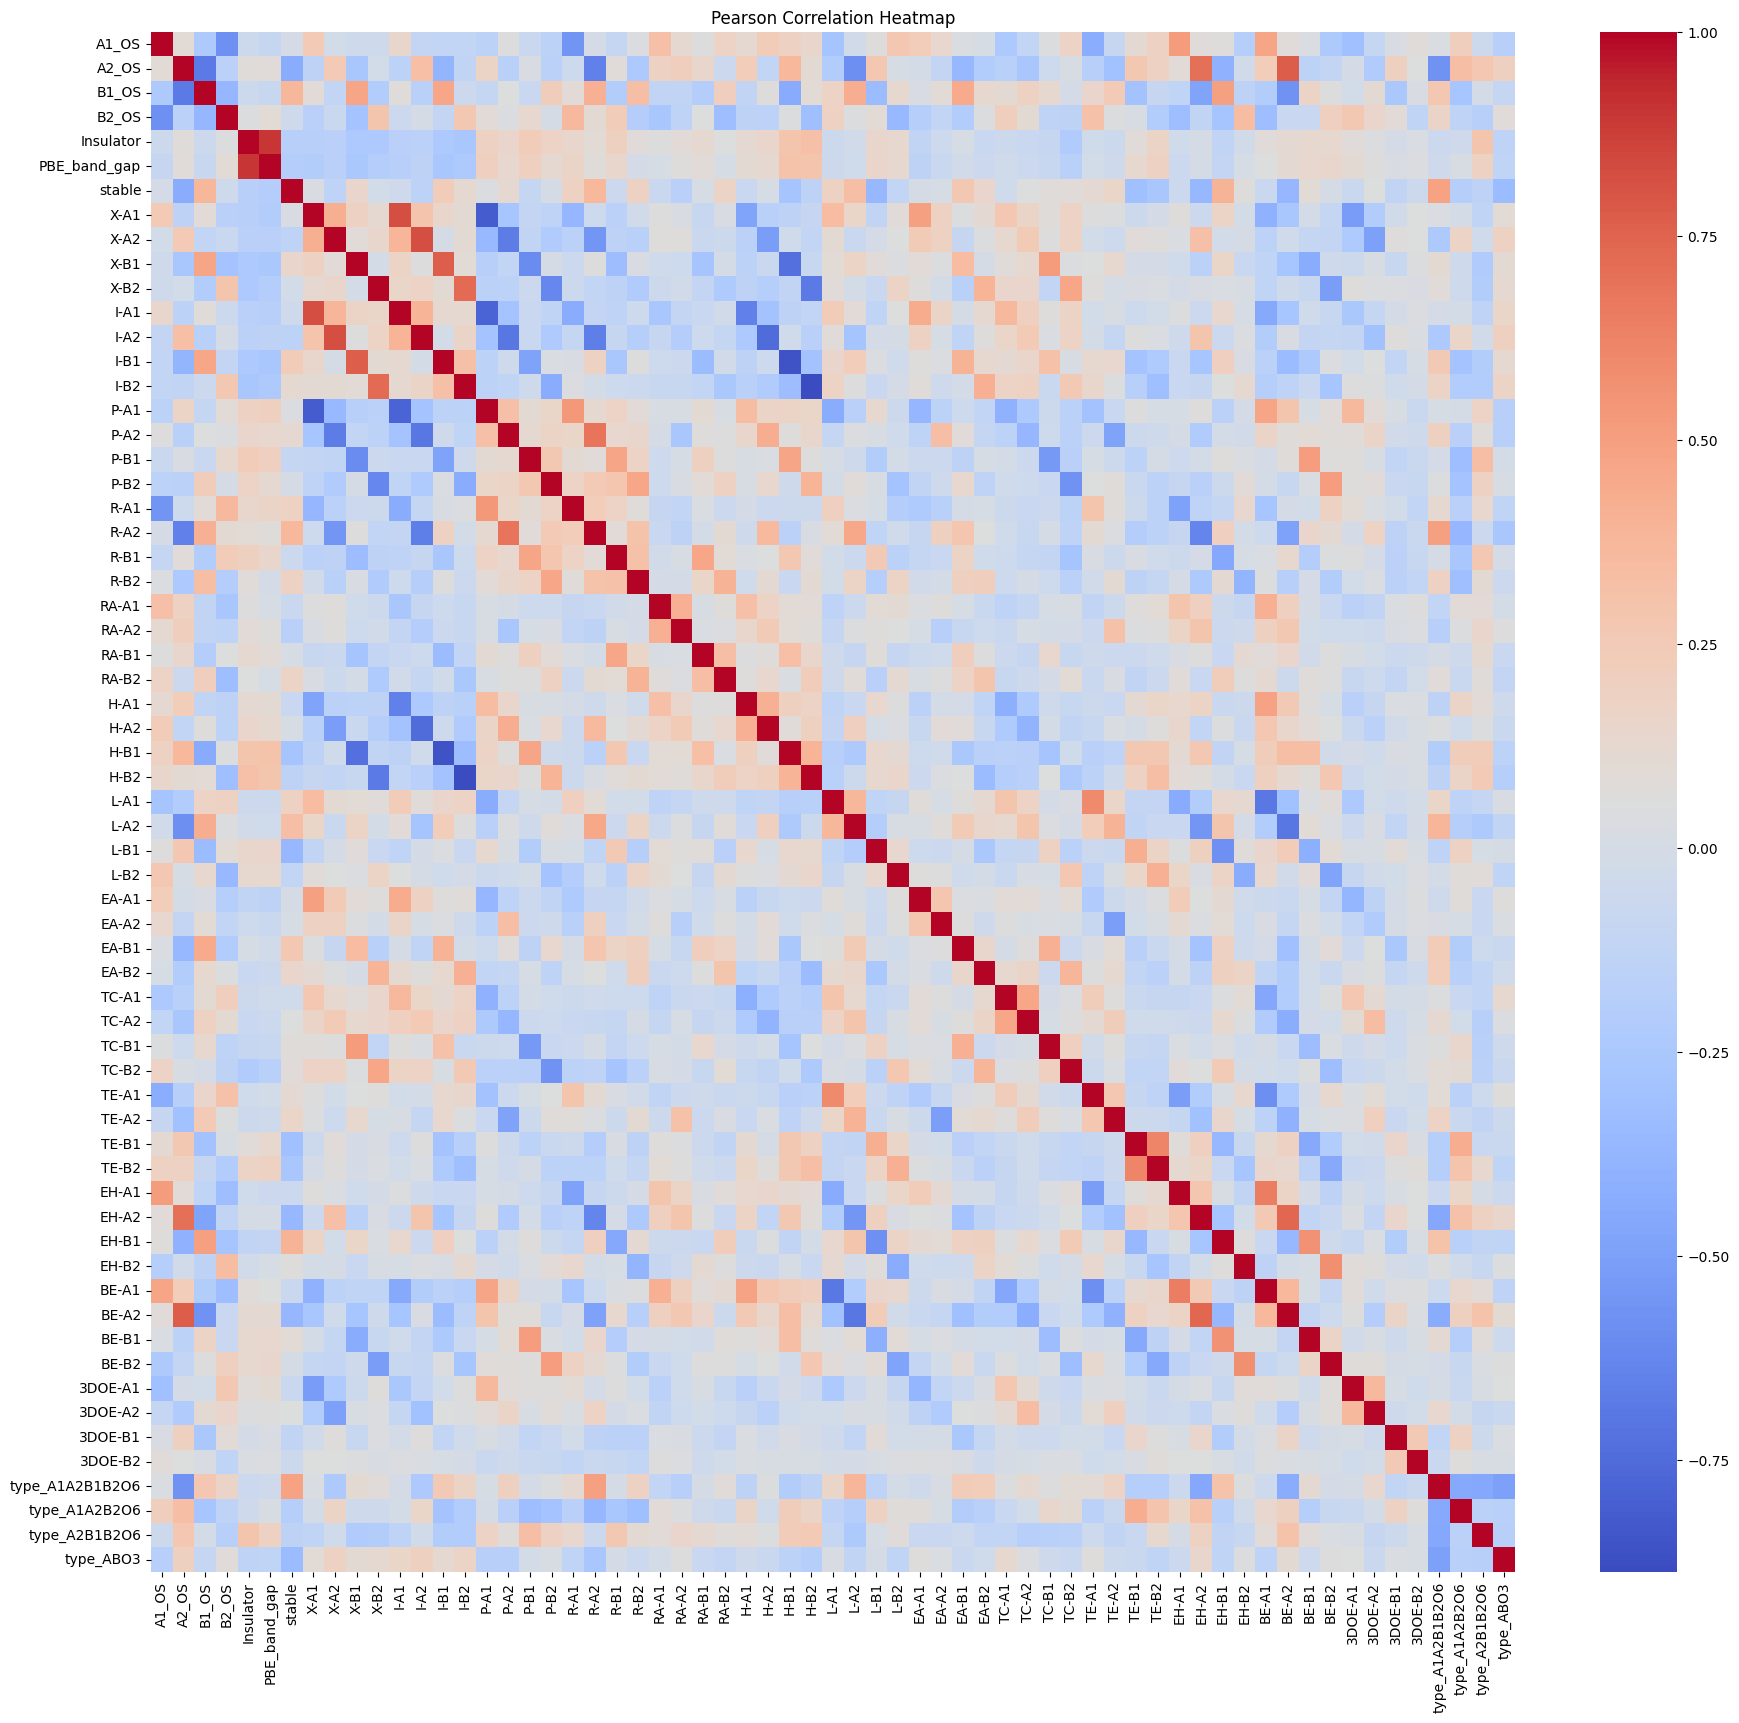

In [6]:
import seaborn as sns

# Calculate correlation matrices
pearson_corr_matrix = df.corr(method='pearson', numeric_only=True)

# Plot Pearson correlation heatmap
plt.figure(figsize=(22, 20))
sns.heatmap(pearson_corr_matrix, cmap='coolwarm', annot=False)
plt.title('Pearson Correlation Heatmap')
plt.show()

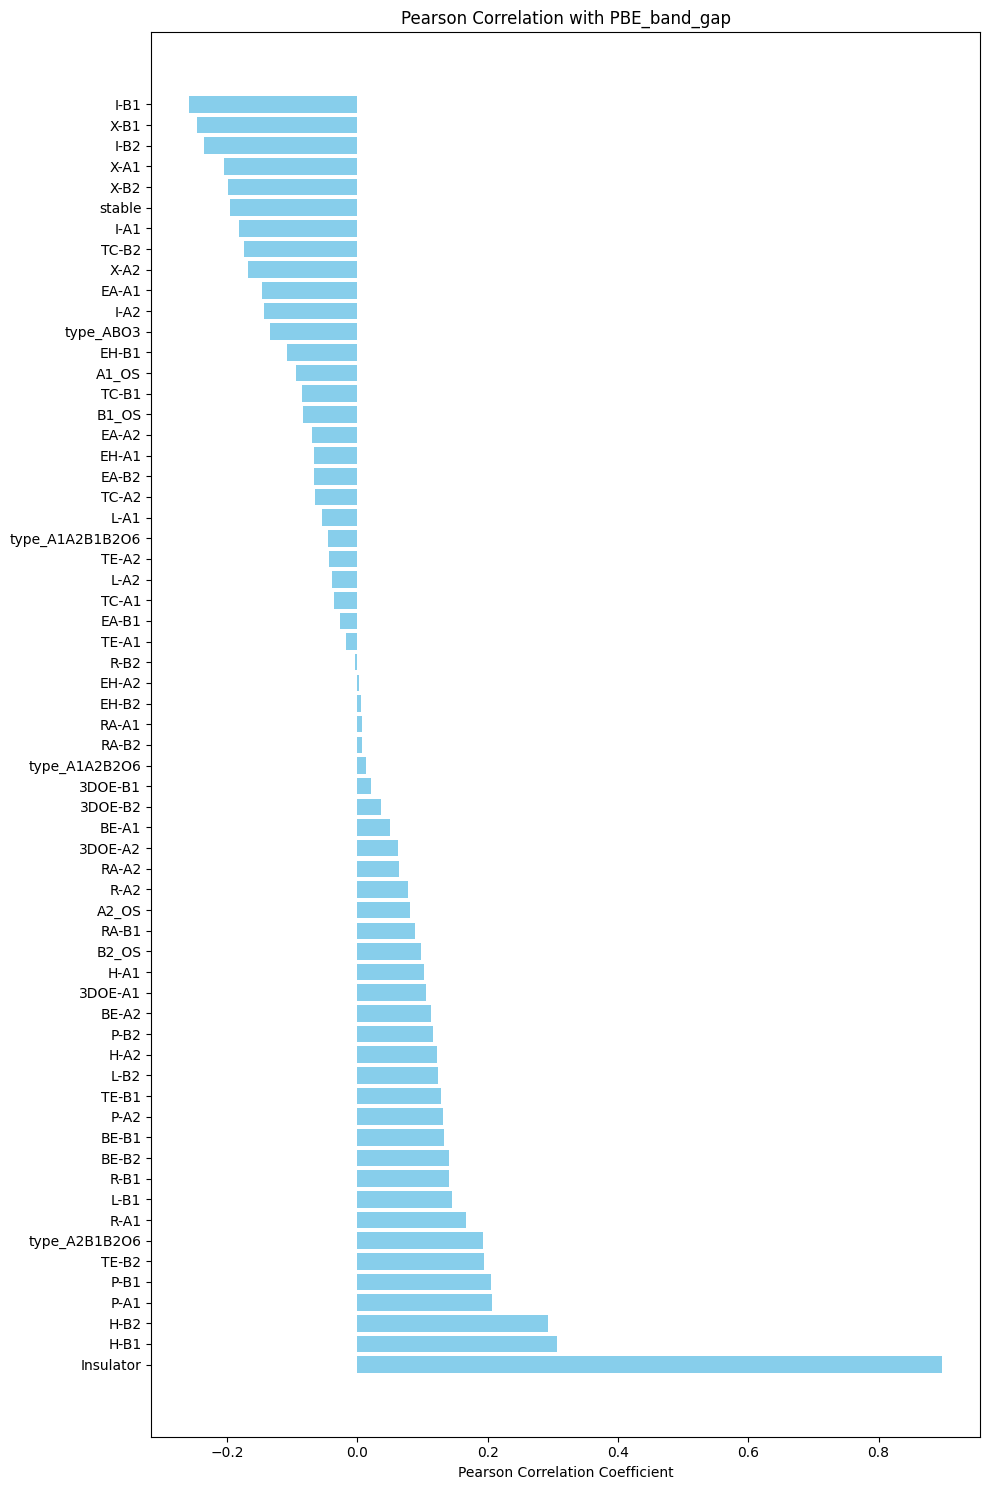

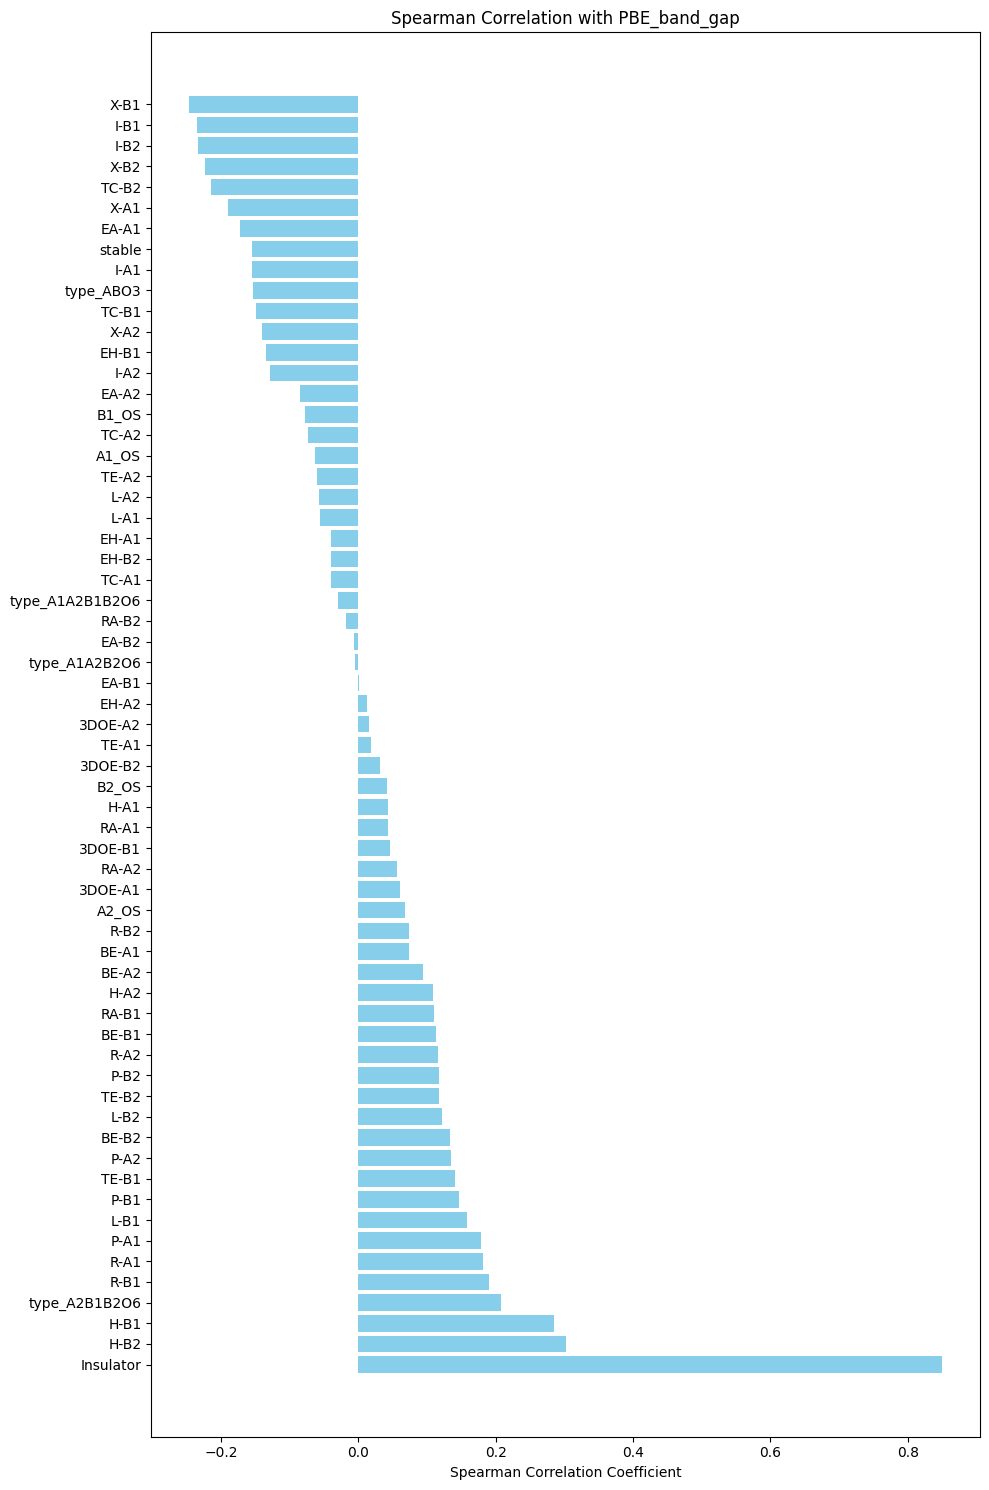

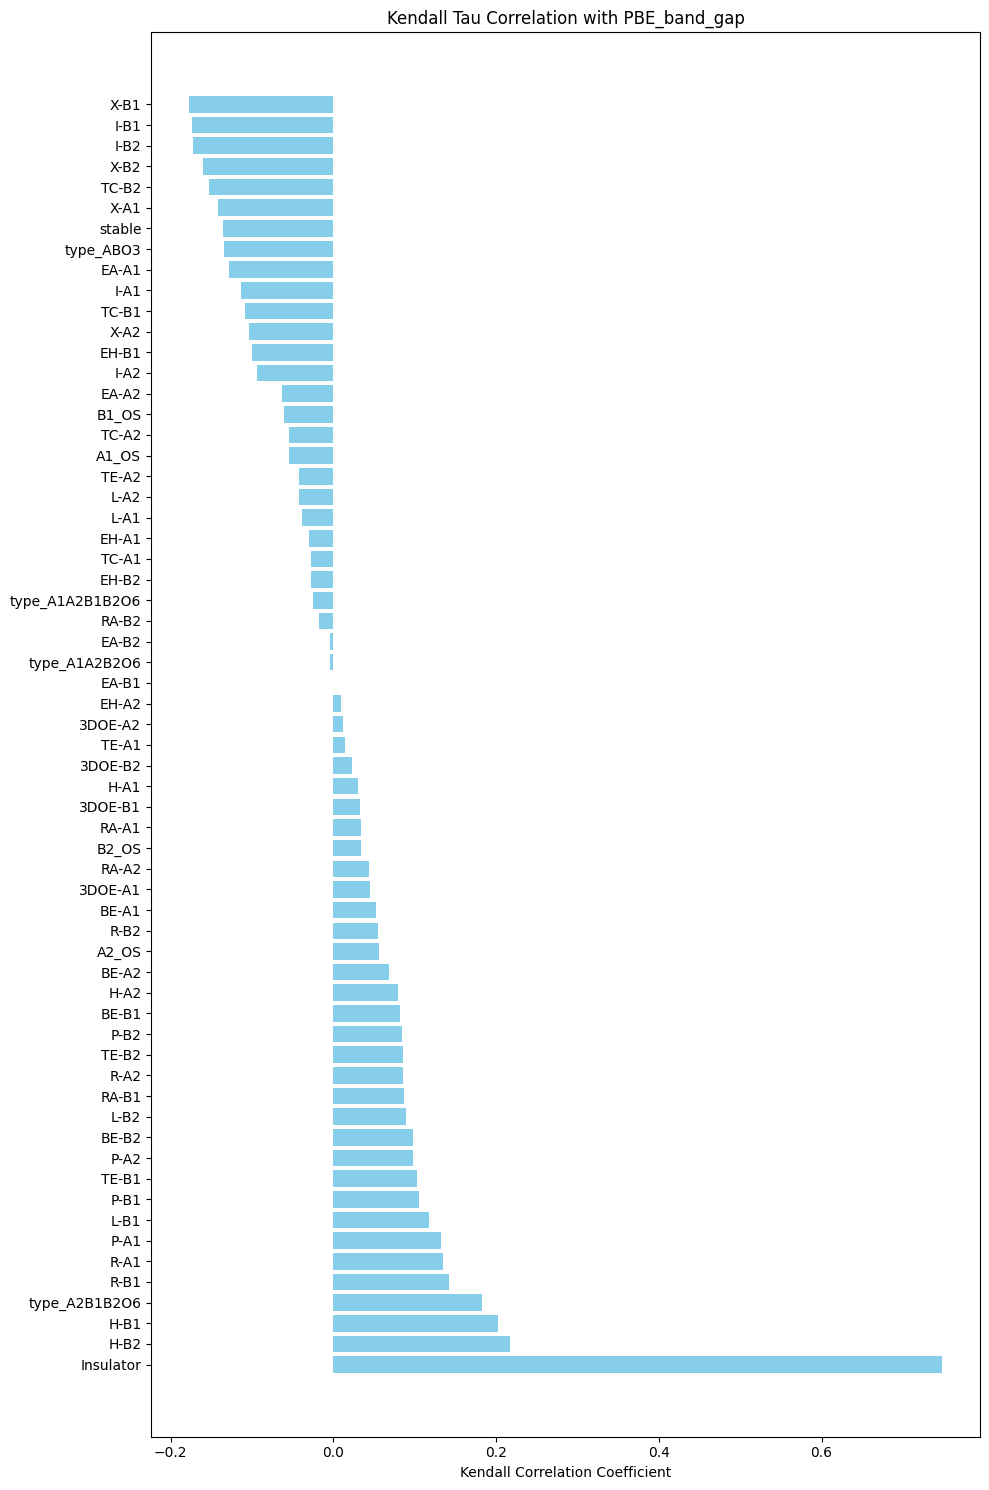

In [7]:
def plot_correlation_barplot(correlation_results, method, title):
    """Plots a horizontal barplot for correlation results."""
    correlations = {col: corrs[method] for col, corrs in correlation_results.items() if corrs[method] is not None}
    sorted_correlations = dict(sorted(correlations.items(), key=lambda item: item[1], reverse=True))

    plt.figure(figsize=(10, 15))
    plt.barh(list(sorted_correlations.keys()), list(sorted_correlations.values()), color='skyblue')
    plt.xlabel(f'{method} Correlation Coefficient')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_correlation_barplot(correlation_results, 'Pearson', 'Pearson Correlation with PBE_band_gap')
plot_correlation_barplot(correlation_results, 'Spearman', 'Spearman Correlation with PBE_band_gap')
plot_correlation_barplot(correlation_results, 'Kendall', 'Kendall Tau Correlation with PBE_band_gap')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5152 entries, 0 to 5151
Data columns (total 63 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_OS            5152 non-null   int64  
 1   A2_OS            5152 non-null   int64  
 2   B1_OS            5152 non-null   int64  
 3   B2_OS            5152 non-null   int64  
 4   Insulator        5152 non-null   int64  
 5   PBE_band_gap     5152 non-null   float64
 6   stable           5152 non-null   int64  
 7   X-A1             5152 non-null   float64
 8   X-A2             5152 non-null   float64
 9   X-B1             5152 non-null   float64
 10  X-B2             5152 non-null   float64
 11  I-A1             5152 non-null   float64
 12  I-A2             5152 non-null   float64
 13  I-B1             5152 non-null   float64
 14  I-B2             5152 non-null   float64
 15  P-A1             5152 non-null   float64
 16  P-A2             5152 non-null   float64
 17  P-B1          

In [9]:
import random
from deap import base, creator, tools
import warnings
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_breast_cancer

# Ignore potential warnings from XGBoost
warnings.filterwarnings('ignore')

# --- Configuration ---
# Order: learning_rate, max_depth, n_estimators, subsample, reg_lambda, reg_alpha, gamma, colsample_bylevel, colsample_bytree
HP_BOUNDS_LOW = [0.01, 3, 50, 0.5, 0, 0, 0, 0.5, 0.5]
HP_BOUNDS_HIGH = [0.3, 15, 500, 1.0, 10, 10, 5, 1.0, 1.0]
# 0: continuous, 1: discrete
HP_TYPES = [0, 1, 1, 0, 0, 0, 0, 0, 0]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters
POPULATION_SIZE = 50
NUM_GENERATIONS = 50
CXPB = 0.7 # Crossover probability
MUTPB = 0.3 # Mutation probability
PATIENCE = 7 # Early stopping patience

# --- DEAP Setup ---
# Define the fitness function (minimize MSE)
# We use 'weights=(-1.0,)' because DEAP minimizes by default, and we want to minimize MSE
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# Define the individual (a list of hyperparameters)
# The individual will have the defined fitness attribute
creator.create("Individual", list, fitness=creator.FitnessMin)

# Create a toolbox to hold the evolutionary operators
toolbox = base.Toolbox()

# Attribute generator: Generate a random value within the bounds for each hyperparameter
# This function will be used to create the initial population
def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    if HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

# Register the attribute generator for each hyperparameter
for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

# Structure initializer: Create an individual by combining the attributes
toolbox.register("individual", tools.initCycle, creator.Individual,
                 tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]), n=1)

# Population initializer: Create a list of individuals
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function ---
def evalXGBR(individual, X_train, y_train, X_val, y_val):
    """
    Evaluates the fitness of an individual (set of hyperparameters)
    by training an XGBoost Regressor and calculating the Mean Squared Error
    on the validation set.
    """

    hyperparameters = {
        'learning_rate': individual[0],
        'max_depth': int(individual[1]),
        'n_estimators': int(individual[2]),
        'subsample': individual[3],
        'reg_lambda': individual[4],
        'reg_alpha': individual[5],
        'gamma': individual[6],
        'colsample_bylevel': individual[7],
        'colsample_bytree': individual[8]
    }

    # Ensure max_depth and n_estimators are at least 1
    hyperparameters['max_depth'] = max(1, hyperparameters['max_depth'])
    hyperparameters['n_estimators'] = max(1, hyperparameters['n_estimators'])


    try:

        model = XGBRegressor(objective='reg:squarederror',
                                 eval_metric='rmse',
                                 use_label_encoder=False, # Deprecated warning fix
                                 random_state=42,
                                 **hyperparameters)


        model.fit(X_train, y_train)
        predictions = model.predict(X_val)
        mse = mean_squared_error(y_val, predictions)
        return (mse,)

    except Exception as e:
        # Handle potential errors during training ( invalid hyperparameters)
        return (float('inf'),) # Assign infinity as fitness

# Register the evaluation function with the toolbox
toolbox.register("evaluate", evalXGBR, X_train=None, y_train=None, X_val=None, y_val=None) # Will set data later

# --- Genetic Operators ---
# Register the crossover operator
toolbox.register("mate", tools.cxTwoPoint)

# Register the mutation operator (Gaussian mutation)
# We use a custom mutation to respect the bounds and types of hyperparameters
def mutate_hyperparameters(individual, mu, sigma, indpb):
    """Mutate an individual's hyperparameters while respecting bounds and types."""
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb: # Mutate with probability indpb
            if hp_type == 0:
                # Apply Gaussian mutation
                individual[i] += random.gauss(mu, sigma[i])
                # Ensure bounds are respected
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            else:
                # Apply integer mutation (add random integer within a range)

                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

# Register the custom mutation operator
# Adjust sigma based on the range of each hyperparameter
hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [r * 0.1 for r in hp_ranges] # mutation strength is 10% of the range
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.1) # indpb is the probability of mutating each attribute

# Register the selection operator (tournament selection)
toolbox.register("select", tools.selTournament, tournsize=3)

def eaSimpleWithEarlyStop(population, toolbox, cxpb, mutpb, ngen, stats=None,
                          halloffame=None, verbose=__debug__, patience=7):

    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the initial population
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    if halloffame is not None:
        halloffame.update(population)

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(population), **record)
    if verbose:
        print(logbook.stream)

    # --- Early stopping vars ---
    best_so_far = min(ind.fitness.values[0] for ind in population)
    no_improve_count = 0

    for gen in range(1, ngen + 1):
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate invalid individuals
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Replace population
        population[:] = offspring

        if halloffame is not None:
            halloffame.update(population)

        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

        # --- Early stopping check ---
        current_best = min(ind.fitness.values[0] for ind in population)
        if current_best < best_so_far:
            best_so_far = current_best
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            if verbose:
                print(f"\nEarly stopping triggered at generation {gen} "
                      f"(no improvement for {patience} generations).")
            break

    return population, logbook
# --- Main Evolutionary Loop ---
if __name__ == '__main__':
    y_total = df["PBE_band_gap"]
    X_total = df.drop(["PBE_band_gap"],axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X_total,y_total,test_size=0.2,random_state=101)

    # X, y = load_breast_cancer(return_X_y=True)
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Update the toolbox with the actual data
    toolbox.unregister("evaluate") # Unregister the placeholder
    toolbox.register("evaluate", evalXGBR, X_train=X_train, y_train=y_train, X_val=X_test, y_val=y_test)

    # Create the initial population
    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    # Evaluate the fitness of the initial population
    print("Evaluating initial population...")
    # Map the evaluation function to the individuals
    fitnesses = list(map(toolbox.evaluate, population))
    # Assign the calculated fitness values to the individuals
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    hof = tools.HallOfFame(1) # Hall of Fame to store the single best individual

    # Create a statistics object to record performance during evolution
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Run the evolutionary algorithm
    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = eaSimpleWithEarlyStop(
        population, toolbox, cxpb=CXPB, mutpb=MUTPB,
        ngen=NUM_GENERATIONS, stats=stats,
        halloffame=hof, verbose=True, patience=PATIENCE
    )


    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        optimal_objective = best_individual.fitness.values[0]

        # Decode the best hyperparameters
        optimal_hyperparameters = {
            'learning_rate': best_individual[0],
            'max_depth': int(best_individual[1]),
            'n_estimators': int(best_individual[2]),
            'subsample': best_individual[3],
            'reg_lambda': best_individual[4],
            'reg_alpha': best_individual[5],
            'gamma': best_individual[6],
            'colsample_bylevel': best_individual[7],
            'colsample_bytree': best_individual[8]
        }

        print(f"Optimization finished. Best Mean Squared Error: {optimal_objective:.4f}")
        print("Optimal Hyperparameters found:")
        for hp, value in optimal_hyperparameters.items():
            print(f"  {hp}: {value}")

    else:
        print("Optimization did not find a valid individual.")



Creating initial population of size 50...
Evaluating initial population...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg      	std      	min      	max     
0  	50    	0.0764782	0.0192717	0.0290998	0.146064
1  	39    	0.0620975	0.0162024	0.0290998	0.112918
2  	42    	0.0476414	0.0132026	0.0227046	0.0775998
3  	41    	0.0375744	0.00909687	0.0227046	0.0677862
4  	40    	0.0302546	0.00442212	0.0220093	0.0432943
5  	39    	0.0278698	0.00547273	0.0198012	0.0536525
6  	44    	0.0236372	0.00354738	0.0198012	0.0403986
7  	43    	0.0224554	0.00360719	0.0188091	0.040503 
8  	43    	0.0210588	0.00141331	0.0182922	0.0266364
9  	39    	0.0210663	0.00484396	0.0177323	0.0496693
10 	38    	0.0195509	0.00113868	0.0177323	0.0229815
11 	40    	0.0193882	0.00211268	0.0177323	0.0331152
12 	39    	0.0195335	0.00354461	0.0177323	0.0411081
13 	37    	0.0196579	0.00296026	0.0177323	0.0338419
14 	38    	0.0186546	0.00153742	0.0175503	0.0270045
15 	44    	0.0185655	0.00220531	0.0175503	0

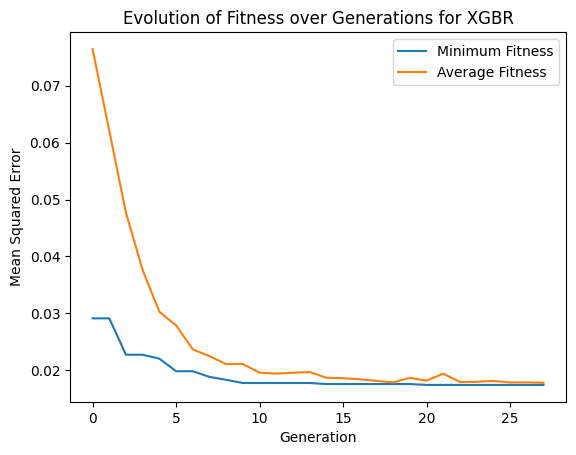

In [10]:
# Plot the statistics
import matplotlib.pyplot as plt
gen = logbook.select("gen")
min_fit = logbook.select("min")
avg_fit = logbook.select("avg")
plt.plot(gen, min_fit, label="Minimum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations for XGBR")
plt.legend()
plt.show()

In [11]:
final_model = XGBRegressor(objective='reg:squarederror',
                                use_label_encoder=False,
                                random_state=42,
                                **optimal_hyperparameters)
final_model.fit(X_train, y_train)
print("\nFinal model trained with optimal hyperparameters.")


Final model trained with optimal hyperparameters.


In [12]:
from sklearn.metrics import r2_score

y_pred = final_model.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)
print(f"Test set Mean Squared Error (MSE): {test_mse:.4f}")
print(f"Test set Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"Test set R-squared (R2): {test_r2:.4f}")

Test set Mean Squared Error (MSE): 0.0174
Test set Root Mean Squared Error (RMSE): 0.1319
Test set R-squared (R2): 0.9845


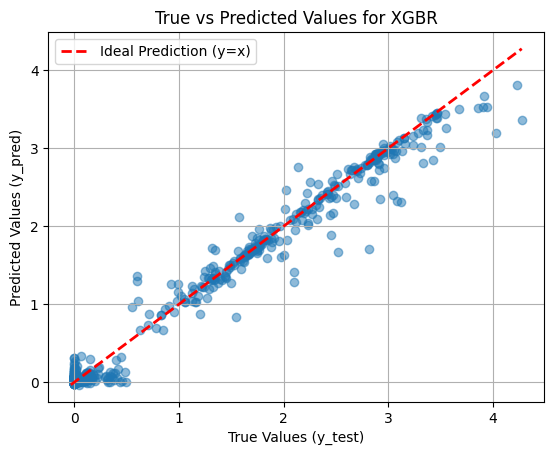

In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)


plt.title('True vs Predicted Values for XGBR')
plt.xlabel('True Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')


min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

# --- Configuration ---
# Order: n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features
HP_BOUNDS_LOW =  [50,  2,  2,  1, 0.1]
HP_BOUNDS_HIGH = [500, 20, 20, 10, 1.0]
# 0 = continuous, 1 = discrete
HP_TYPES = [1, 1, 1, 1, 0]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters
POPULATION_SIZE = 30
NUM_GENERATIONS = 50
CXPB = 0.7   # Crossover probability
MUTPB = 0.3  # Mutation probability
PATIENCE = 5 # Early stopping patience

# --- DEAP Setup ---
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)
toolbox = base.Toolbox()

# Attribute generator
def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    if HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

# Register attributes
for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

# Structure initializers
toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]),
    n=1,
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function ---
def evalRFR(individual, X_train, y_train, X_val, y_val):
    """
    Evaluates the fitness of an individual (set of hyperparameters)
    by training a RandomForestRegressor and calculating the MSE.
    """
    hyperparameters = {
        "n_estimators": int(individual[0]),
        "max_depth": int(individual[1]),
        "min_samples_split": int(individual[2]),
        "min_samples_leaf": int(individual[3]),
        "max_features": individual[4],
        "random_state": 42,
        "n_jobs": -1,
    }
    try:
        model = RandomForestRegressor(**hyperparameters)
        model.fit(X_train, y_train)
        predictions = model.predict(X_val)
        mse = mean_squared_error(y_val, predictions)
        return (mse,)
    except Exception:
        return (float("inf"),)

# Register evaluation placeholder
toolbox.register("evaluate", evalRFR, X_train=None, y_train=None, X_val=None, y_val=None)

# --- Genetic Operators ---
toolbox.register("mate", tools.cxTwoPoint) 

def mutate_hyperparameters(individual, mu, sigma, indpb):
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb:
            if hp_type == 0:  # continuous
                individual[i] += random.gauss(mu, sigma[i])
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            else:  # integer
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [r * 0.1 for r in hp_ranges]
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# --- Evolutionary Algorithm with Early Stopping ---
def eaSimpleWithEarlyStop(population, toolbox, cxpb, mutpb, ngen, stats=None,
                          halloffame=None, verbose=__debug__, patience=5):

    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the initial population
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    if halloffame is not None:
        halloffame.update(population)

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(population), **record)
    if verbose:
        print(logbook.stream)

    # --- Early stopping vars ---
    best_so_far = min(ind.fitness.values[0] for ind in population)
    no_improve_count = 0

    for gen in range(1, ngen + 1):
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate invalid individuals
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Replace population
        population[:] = offspring

        if halloffame is not None:
            halloffame.update(population)

        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

        # --- Early stopping check ---
        current_best = min(ind.fitness.values[0] for ind in population)
        if current_best < best_so_far:
            best_so_far = current_best
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            if verbose:
                print(f"\nEarly stopping triggered at generation {gen} "
                      f"(no improvement for {patience} generations).")
            break

    return population, logbook

# --- Main Run ---
if __name__ == "__main__":

    y_total = df["PBE_band_gap"]
    X_total = df.drop(["PBE_band_gap"],axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X_total,y_total,test_size=0.2,random_state=101)
    # Update toolbox evaluate with actual data
    toolbox.unregister("evaluate")
    toolbox.register("evaluate", evalRFR, X_train=X_train, y_train=y_train,
                     X_val=X_test, y_val=y_test)

    # Initialize population
    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    # Statistics
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    hof = tools.HallOfFame(1)

    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = eaSimpleWithEarlyStop(
        population, toolbox, cxpb=CXPB, mutpb=MUTPB,
        ngen=NUM_GENERATIONS, stats=stats,
        halloffame=hof, verbose=True, patience=PATIENCE
    )

    # --- Results ---
    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        optimal_objective = best_individual.fitness.values[0]
        optimal_hyperparameters = {
            "n_estimators": int(best_individual[0]),
            "max_depth": int(best_individual[1]),
            "min_samples_split": int(best_individual[2]),
            "min_samples_leaf": int(best_individual[3]),
            "max_features": best_individual[4],
        }

        print(f"Best Mean Squared Error: {optimal_objective:.4f}")
        print("Best Hyperparameters:")
        for hp, value in optimal_hyperparameters.items():
            print(f"  {hp}: {value}")
    else:
        print("No valid individual found.")


Creating initial population of size 30...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg    	std      	min      	max    
0  	30    	0.10102	0.0986709	0.0291703	0.39794
1  	29    	0.0419341	0.0181873	0.0259476	0.121748
2  	26    	0.0334405	0.00458131	0.0264419	0.0479792
3  	26    	0.0303871	0.00384916	0.0254831	0.0413348
4  	27    	0.0302805	0.0101447 	0.0253656	0.0827449
5  	15    	0.0263954	0.000882793	0.0242809	0.0281896
6  	28    	0.0291299	0.0113626  	0.0242809	0.0866801
7  	21    	0.0282727	0.0112447  	0.0246771	0.0869218
8  	23    	0.0262432	0.00315    	0.0243936	0.0399766
9  	25    	0.0270691	0.0104851  	0.0237164	0.0833741
10 	29    	0.0247721	0.000471964	0.0237164	0.0263751
11 	23    	0.0258455	0.00366693 	0.0237164	0.0402409
12 	27    	0.0268436	0.0106188  	0.0237164	0.0834351
13 	26    	0.0258132	0.00585276 	0.0236622	0.0515192
14 	20    	0.024417 	0.00284207 	0.022969 	0.0395749
15 	21    	0.0252334	0.00475423 	0.022969 	0.045268 
16 	23    	0.02763

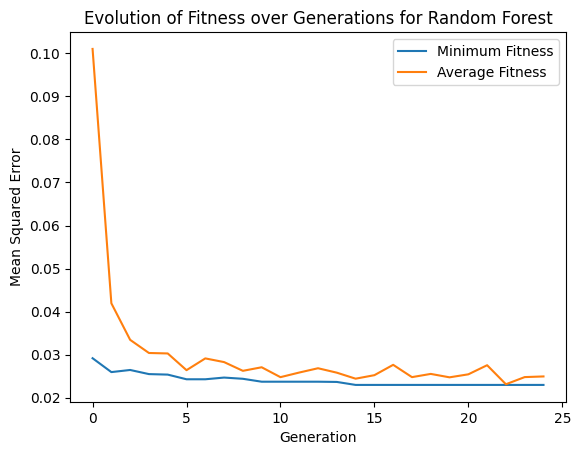

In [15]:
# Plot the statistics
import matplotlib.pyplot as plt
gen = logbook.select("gen")
min_fit = logbook.select("min")
avg_fit = logbook.select("avg")
plt.plot(gen, min_fit, label="Minimum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations for Random Forest")
plt.legend()
plt.show()

In [16]:
final_model_random = RandomForestRegressor(random_state=42,
                                **optimal_hyperparameters)
final_model_random.fit(X_train, y_train)
print("\nFinal model trained with optimal hyperparameters.")


Final model trained with optimal hyperparameters.


In [17]:
y_pred_random = final_model_random.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred_random)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_random)
print(f"Test set Mean Squared Error (MSE): {test_mse:.4f}")
print(f"Test set Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"Test set R-squared (R2): {test_r2:.4f}")

Test set Mean Squared Error (MSE): 0.0230
Test set Root Mean Squared Error (RMSE): 0.1516
Test set R-squared (R2): 0.9795


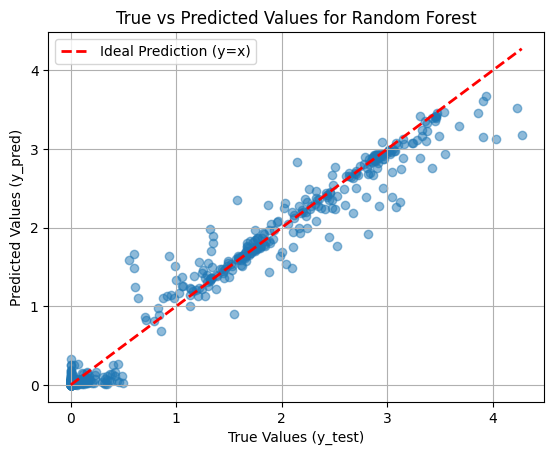

In [18]:
plt.scatter(y_test, y_pred_random, alpha=0.5)


plt.title('True vs Predicted Values for Random Forest')
plt.xlabel('True Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')


min_val = min(min(y_test), min(y_pred_random))
max_val = max(max(y_test), max(y_pred_random))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:

from sklearn.svm import SVR
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

# --- Configuration ---
# Order: C, epsilon, gamma
HP_BOUNDS_LOW =  [0.1, 0.001, 1e-5]
HP_BOUNDS_HIGH = [1000, 1.0, 1.0]
# 0 = continuous, 1 = discrete
HP_TYPES = [0, 0, 0]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters
POPULATION_SIZE = 30
NUM_GENERATIONS = 50
CXPB = 0.7   # Crossover probability
MUTPB = 0.3  # Mutation probability
PATIENCE = 7 # Early stopping patience

# --- DEAP Setup ---
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)
toolbox = base.Toolbox()

# Attribute generator
def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    if HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

# Register attributes
for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

# Structure initializers
toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]),
    n=1,
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function ---
def evalSVR(individual, X_train, y_train, X_val, y_val):
    """
    Evaluates the fitness of an individual (set of hyperparameters)
    by training an SVR and calculating the MSE.
    """
    hyperparameters = {
        "C": individual[0],
        "epsilon": individual[1],
        "gamma": individual[2],
        "kernel": "rbf",
    }
    try:
        model = SVR(**hyperparameters)
        model.fit(X_train, y_train)
        predictions = model.predict(X_val)
        mse = mean_squared_error(y_val, predictions)
        return (mse,)
    except Exception as e:
        print("Error during evaluation:", e)
        return (float("inf"),)

# Register evaluation placeholder
toolbox.register("evaluate", evalSVR, X_train=None, y_train=None, X_val=None, y_val=None)

# --- Genetic Operators ---
toolbox.register("mate", tools.cxTwoPoint)

def mutate_hyperparameters(individual, mu, sigma, indpb):
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb:
            if hp_type == 0:  # continuous
                individual[i] += random.gauss(mu, sigma[i])
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            else:  # integer
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [r * 0.1 for r in hp_ranges]
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# --- Evolutionary Algorithm with Early Stopping ---
def eaSimpleWithEarlyStop(population, toolbox, cxpb, mutpb, ngen, stats=None,
                          halloffame=None, verbose=__debug__, patience=5):

    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the initial population
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    if halloffame is not None:
        halloffame.update(population)

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(population), **record)
    if verbose:
        print(logbook.stream)

    # --- Early stopping vars ---
    best_so_far = min(ind.fitness.values[0] for ind in population)
    no_improve_count = 0

    for gen in range(1, ngen + 1):
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate invalid individuals
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Replace population
        population[:] = offspring

        if halloffame is not None:
            halloffame.update(population)

        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

        # --- Early stopping check ---
        current_best = min(ind.fitness.values[0] for ind in population)
        if current_best < best_so_far:
            best_so_far = current_best
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            if verbose:
                print(f"\nEarly stopping triggered at generation {gen} "
                      f"(no improvement for {patience} generations).")
            break

    return population, logbook

# --- Main Run ---
if __name__ == "__main__":

    y_total = df["PBE_band_gap"]
    X_total = df.drop(["PBE_band_gap"], axis=1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_total, y_total, test_size=0.2, random_state=101
    )
    imputer = SimpleImputer(strategy='mean') # Common choice for numerical data


    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)


    # --- Scale both X and y ---
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_train_scaled = scaler_X.fit_transform(X_train_imputed)
    X_test_scaled = scaler_X.transform(X_test_imputed)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

    # Update toolbox evaluate with actual data
    toolbox.unregister("evaluate")
    toolbox.register("evaluate", evalSVR,
                     X_train=X_train_scaled, y_train=y_train_scaled,
                     X_val=X_test_scaled, y_val=y_test_scaled)

    # Initialize population
    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    # Statistics
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    hof = tools.HallOfFame(1)

    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = eaSimpleWithEarlyStop(
        population, toolbox, cxpb=CXPB, mutpb=MUTPB,
        ngen=NUM_GENERATIONS, stats=stats,
        halloffame=hof, verbose=True, patience=PATIENCE
    )

    # --- Results ---
    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        optimal_objective = best_individual.fitness.values[0]
        optimal_hyperparameters = {
            "C": best_individual[0],
            "epsilon": best_individual[1],
            "gamma": best_individual[2],
            "kernel": "rbf",
        }

        print(f"Best Mean Squared Error: {optimal_objective:.4f}")
        print("Best Hyperparameters:")
        for hp, value in optimal_hyperparameters.items():
            print(f"  {hp}: {value}")
    else:
        print("No valid individual found.")



Creating initial population of size 30...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg     	std     	min     	max   
0  	30    	0.708369	0.274875	0.110054	1.1795
1  	26    	0.517168	0.263387	0.060003	0.978281
2  	25    	0.298527	0.175235	0.0537056	0.704298
3  	28    	0.153064	0.0989622	0.0537056	0.568945
4  	25    	0.075458	0.0249283	0.0516184	0.154074
5  	23    	0.0752881	0.0754969	0.0516184	0.473465
6  	27    	0.06881  	0.0490371	0.0516184	0.284862
7  	28    	0.0567342	0.0232139	0.0502791	0.181586
8  	23    	0.053675 	0.0108428	0.0479103	0.111491
9  	21    	0.0733795	0.0543757	0.0479103	0.222785
10 	21    	0.0514832	0.00338634	0.0479103	0.0677912
11 	25    	0.0675353	0.0450799 	0.0479103	0.204115 
12 	25    	0.0647619	0.0519868 	0.0479103	0.288781 
13 	28    	0.0630511	0.0517852 	0.0479103	0.285935 
14 	26    	0.0604901	0.0414317 	0.0457706	0.215072 
15 	26    	0.0621993	0.0498719 	0.0457706	0.288781 
16 	23    	0.0716715	0.0626792 	0.0457706	0.288781 
17 	

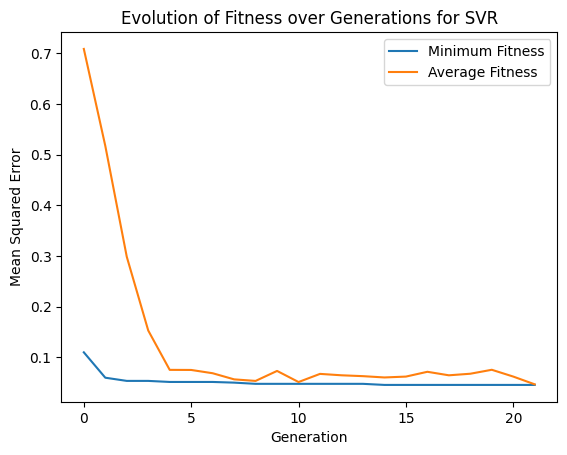

In [20]:
import matplotlib.pyplot as plt
gen = logbook.select("gen")
min_fit = logbook.select("min")
avg_fit = logbook.select("avg")
plt.plot(gen, min_fit, label="Minimum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations for SVR")
plt.legend()
plt.show()

In [21]:
from sklearn.svm import SVR


# 'C', 'epsilon', 'gamma', and 'kernel' (e.g., {'C': ..., 'epsilon': ..., 'gamma': ..., 'kernel': 'rbf'})
# and X_train, y_train are your preprocessed training data.

final_svr_model = SVR(
    C=optimal_hyperparameters['C'],
    epsilon=optimal_hyperparameters['epsilon'],
    gamma=optimal_hyperparameters['gamma'],
    kernel=optimal_hyperparameters['kernel'] # This will be 'rbf' based on our setup
)

# Fit the SVR model using your preprocessed training data
final_svr_model.fit(X_train_scaled, y_train)

print("\nFinal SVR model trained with optimal hyperparameters.")


Final SVR model trained with optimal hyperparameters.


In [22]:
y_pred_svr = final_svr_model.predict(X_test_scaled)

test_mse = mean_squared_error(y_test, y_pred_svr)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_svr)
print(f"Test set Mean Squared Error (MSE): {test_mse:.4f}")
print(f"Test set Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"Test set R-squared (R2): {test_r2:.4f}")

Test set Mean Squared Error (MSE): 0.0492
Test set Root Mean Squared Error (RMSE): 0.2219
Test set R-squared (R2): 0.9561


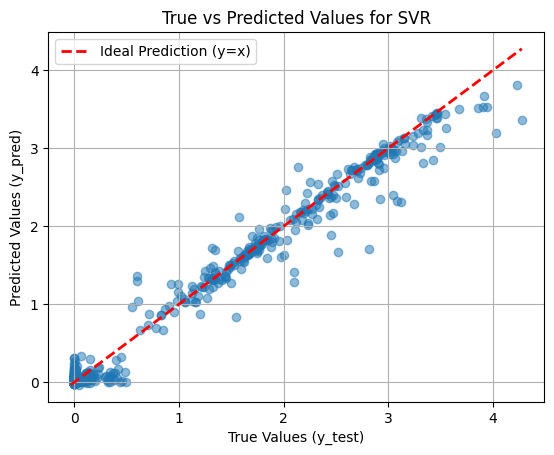

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)


plt.title('True vs Predicted Values for SVR')
plt.xlabel('True Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')


min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction (y=x)')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import joblib
import os


os.makedirs('/Users/sohanurrahman/Desktop/research/perovskite/oxide/code/model/bandgap', exist_ok=True)

joblib.dump(final_model, '/Users/sohanurrahman/Desktop/research/perovskite/oxide/code/model/bandgap/xgbr_model.joblib')

joblib.dump(final_model_random, '/Users/sohanurrahman/Desktop/research/perovskite/oxide/code/model/bandgap/rf_model.joblib')

joblib.dump(final_svr_model, '/Users/sohanurrahman/Desktop/research/perovskite/oxide/code/model/bandgap/svr_model.joblib')

print("Models saved successfully as joblib files in the 'model' directory.")

Models saved successfully as joblib files in the 'model' directory.
